# Classification using popular algorithms

In this file classification using 5 popular algorithms is conducted. This is implementation of the 5-th part of the project.

In [4]:
import pandas as pd

In [ ]:
!pip3 install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd

data = pd.read_csv("cleaned_encoded_data.csv")
data = data.drop(columns=[x for x in data if x.endswith('_intervals')])
data = data.drop(columns=['Education', 'JoiningYear','PaymentTier', 'Age', 'ExperienceInCurrentDomain'])
data.head()

,LeaveOrNot,city_is_bangalore,city_is_pune,city_is_new_delhi,gender_is_male,gender_is_female,is_ever_benched,is_never_benched,Education_categories,JoiningYear_categories,PaymentTier_categories,Age_categories,ExperienceInCurrentDomain_categories
0,0,1,0,0,1,0,0,1,1,5,3,12,0
1,1,0,1,0,0,1,0,1,1,1,1,6,3
2,0,0,0,1,0,1,0,1,1,2,3,16,2
3,1,1,0,0,1,0,0,1,2,4,3,5,5
4,1,0,1,0,1,0,1,0,2,5,3,2,2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3326 entries, 0 to 3325
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   LeaveOrNot                            3326 non-null   int64
 1   city_is_bangalore                     3326 non-null   int64
 2   city_is_pune                          3326 non-null   int64
 3   city_is_new_delhi                     3326 non-null   int64
 4   gender_is_male                        3326 non-null   int64
 5   gender_is_female                      3326 non-null   int64
 6   is_ever_benched                       3326 non-null   int64
 7   is_never_benched                      3326 non-null   int64
 8   Education_categories                  3326 non-null   int64
 9   JoiningYear_categories                3326 non-null   int64
 10  PaymentTier_categories                3326 non-null   int64
 11  Age_categories                        3326 

In [13]:
data.to_csv('good_data.csv', index = False)

Optuna пока не устанавливаю, так как крутится FCA. Завтра переделаю с оптуной

# 1) SVM

In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [19]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
import optuna

def objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf']),
        'gamma': trial.suggest_float('gamma', 0.001, 10.0, log=True),
    }
    
    model = SVC(**params, random_state=42)
    
    # Быстрая кросс-валидация
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_scaled, y_train, 
                           cv=3, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Оптимизация
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Лучшая модель
best_svm = SVC(**study.best_params, random_state=42)
best_svm.fit(X_train_scaled, y_train)

# Результаты
y_pred = best_svm.predict(X_test_scaled)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-02 08:37:58,244] A new study created in memory with name: no-name-3905109d-e7d7-47e5-85d1-429035163685
[I 2025-12-02 08:38:00,534] Trial 0 finished with value: 0.6144379676324895 and parameters: {'C': 4.4022116570866885, 'kernel': 'linear', 'gamma': 0.013222940104940694}. Best is trial 0 with value: 0.6144379676324895.
[I 2025-12-02 08:38:01,486] Trial 1 finished with value: 0.6150547188145121 and parameters: {'C': 14.671100319293501, 'kernel': 'linear', 'gamma': 0.003844804457283381}. Best is trial 1 with value: 0.6150547188145121.
[I 2025-12-02 08:38:01,905] Trial 2 finished with value: 0.7546191298300502 and parameters: {'C': 70.58180237452187, 'kernel': 'rbf', 'gamma': 2.314482475365444}. Best is trial 2 with value: 0.754619129830

# 2) Decision tree

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

In [26]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    
    tree = DecisionTreeClassifier(**params, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=3, scoring='f1')
    return scores.mean()

# Оптимизация
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Лучшая модель
best_tree = DecisionTreeClassifier(**study.best_params, random_state=42)
best_tree.fit(X_train, y_train)

# Результаты
y_pred = best_tree.predict(X_test)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Размер классификатора
node_indicator = best_tree.decision_path(X_test)
n_nodes = best_tree.tree_.node_count

path_lengths = node_indicator.getnnz(axis=1)
avg_rule_length = np.mean(path_lengths)

importances = best_tree.feature_importances_
feature_names = X_train.columns
tree_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(f"Средняя длина правила (глубина): {avg_rule_length:.2f}")

[I 2025-12-02 08:38:16,031] A new study created in memory with name: no-name-6e9c9f6c-2747-4c67-82ee-cfc0123af0bb
[I 2025-12-02 08:38:16,061] Trial 0 finished with value: 0.854305345950409 and parameters: {'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 10, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854305345950409.
[I 2025-12-02 08:38:16,086] Trial 1 finished with value: 0.8531369220685366 and parameters: {'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854305345950409.
[I 2025-12-02 08:38:16,110] Trial 2 finished with value: 0.8532534503646755 and parameters: {'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 15, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854305345950409.
[I 2025-12-02 08:38:16,141] Trial 3 finished with value: 0.8482448903040122 and parameters: {'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 0 

# 3) Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [35]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

[I 2025-12-02 08:39:35,207] A new study created in memory with name: no-name-049dd7ef-92af-4ace-8571-6dfa9fb4110b
[I 2025-12-02 08:39:35,947] Trial 0 finished with value: 0.8631347894219883 and parameters: {'max_depth': 12, 'min_samples_split': 7, 'criterion': 'gini'}. Best is trial 0 with value: 0.8631347894219883.
[I 2025-12-02 08:39:36,572] Trial 1 finished with value: 0.8344926452256295 and parameters: {'max_depth': 7, 'min_samples_split': 10, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8631347894219883.
[I 2025-12-02 08:39:37,278] Trial 2 finished with value: 0.8670312593092883 and parameters: {'max_depth': 10, 'min_samples_split': 3, 'criterion': 'gini'}. Best is trial 2 with value: 0.8670312593092883.
[I 2025-12-02 08:39:37,978] Trial 3 finished with value: 0.8600633950069762 and parameters: {'max_depth': 12, 'min_samples_split': 8, 'criterion': 'entropy'}. Best is trial 2 with value: 0.8670312593092883.
[I 2025-12-02 08:39:38,694] Trial 4 finished with value: 0.86136

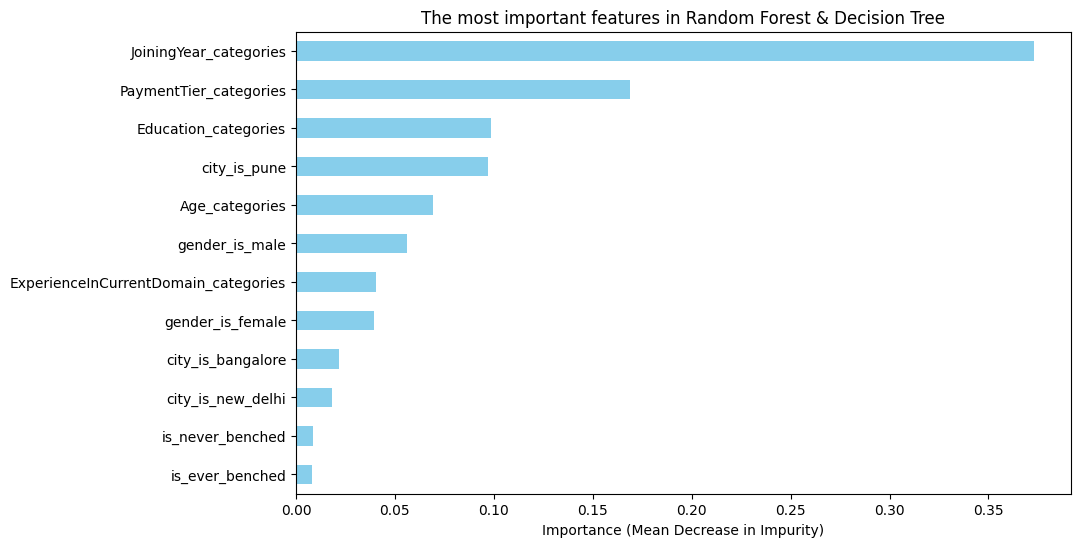

In [ ]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    
    rf = RandomForestClassifier(**params, random_state=42)
    return cross_val_score(rf, X_train, y_train, cv=3, scoring='f1').mean()

# Запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Обучение лучшей модели
best_rf = RandomForestClassifier(**study.best_params, random_state=42)
best_rf.fit(X_train, y_train)

# Оценка
y_pred = best_rf.predict(X_test)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# --- ЧАСТЬ 1: Размер классификатора (Средняя глубина) ---

# У нас есть 100 деревьев. Мы берем глубину каждого и считаем среднее.
# estimator.get_depth() возвращает максимальную глубину конкретного дерева.
depths = [estimator.get_depth() for estimator in best_rf.estimators_]
avg_forest_depth = np.mean(depths)

print(f"=== Размеры классификатора Random Forest ===")
print(f"Количество деревьев (голосующих правил): {len(best_rf.estimators_)}")
print(f"Средняя глубина одного дерева (аналог длины правила): {avg_forest_depth:.2f}")
print(f"Мин. глубина: {min(depths)}, Макс. глубина: {max(depths)}")


# --- ЧАСТЬ 2: Самые полезные атрибуты (Feature Importance) ---

# Получаем важности (сумма равна 1)
importances = best_rf.feature_importances_
# Имена колонок (убедимся, что они в том же порядке, что и при обучении)
feature_names = X_train.columns

# Создаем DataFrame для удобства
forest_importances = pd.Series(importances, index=feature_names)

# Сортируем по убыванию
forest_features = forest_importances.sort_values(ascending=False)
top_features = ((forest_features + tree_importances)/2).sort_values(ascending=False)

print("\n=== Топ-5 самых важных признаков ===")
print(top_features)



# 4) Naive Bayes

In [18]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def objective(trial):
    # Выбираем тип Naive Bayes
    model_type = trial.suggest_categorical('model_type', ['gaussian', 'multinomial', 'bernoulli'])
    
    if model_type == 'gaussian':
        model = GaussianNB(var_smoothing=trial.suggest_float('var_smoothing', 1e-11, 1e-1, log=True))
        X_train_used, X_test_used = X_train, X_test
    else:
        alpha = trial.suggest_float('alpha', 0.1, 10.0)
        if model_type == 'multinomial':
            model = MultinomialNB(alpha=alpha)
        else:  # bernoulli
            model = BernoulliNB(alpha=alpha)
        X_train_used, X_test_used = X_train_scaled, X_test_scaled
    
    scores = cross_val_score(model, X_train_used, y_train, cv=3, scoring='f1')
    return scores.mean()

# Оптимизация
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Обучение лучшей модели
best_params = study.best_params
model_type = best_params.pop('model_type')

if model_type == 'gaussian':
    best_model = GaussianNB(**best_params)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
else:
    if model_type == 'multinomial':
        best_model = MultinomialNB(**best_params)
    else:
        best_model = BernoulliNB(**best_params)
    best_model.fit(X_train_scaled, y_train)
    y_pred = best_model.predict(X_test_scaled)


# Результаты
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

[I 2025-12-02 01:00:18,477] A new study created in memory with name: no-name-198bb724-9079-4cbd-b097-465b5f8e60d3
[I 2025-12-02 01:00:18,487] Trial 0 finished with value: 0.5678033604153195 and parameters: {'model_type': 'bernoulli', 'alpha': 4.652889600596127}. Best is trial 0 with value: 0.5678033604153195.
[I 2025-12-02 01:00:18,494] Trial 1 finished with value: 0.5956217685538446 and parameters: {'model_type': 'gaussian', 'var_smoothing': 1.508655920089107e-05}. Best is trial 1 with value: 0.5956217685538446.
[I 2025-12-02 01:00:18,499] Trial 2 finished with value: 0.5530039107885674 and parameters: {'model_type': 'multinomial', 'alpha': 7.545926643409728}. Best is trial 1 with value: 0.5956217685538446.
[I 2025-12-02 01:00:18,505] Trial 3 finished with value: 0.5530039107885674 and parameters: {'model_type': 'multinomial', 'alpha': 5.72400261256395}. Best is trial 1 with value: 0.5956217685538446.
[I 2025-12-02 01:00:18,511] Trial 4 finished with value: 0.6033330343323892 and para

# 5) KNN

In [20]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

def objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 10),
        'leaf_size': trial.suggest_int('leaf_size', 1, 50),
        'p': trial.suggest_float('p', 1, 10),
    }
    
    knn = KNeighborsClassifier(**params)
    return cross_val_score(knn, X_train, y_train, cv=3, scoring='f1').mean()


# Оптимизация
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Лучшая модель
best_knn = KNeighborsClassifier(**study.best_params)
best_knn.fit(X_train_scaled, y_train)

# Результаты
y_pred = best_knn.predict(X_test_scaled)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

[I 2025-12-02 01:00:18,671] A new study created in memory with name: no-name-49273312-4292-408f-a0f9-b4b7ffdc522f
[I 2025-12-02 01:00:18,749] Trial 0 finished with value: 0.7428738874673385 and parameters: {'n_neighbors': 1, 'leaf_size': 10, 'p': 1.6661608616193055}. Best is trial 0 with value: 0.7428738874673385.
[I 2025-12-02 01:00:18,845] Trial 1 finished with value: 0.6857310213753386 and parameters: {'n_neighbors': 9, 'leaf_size': 13, 'p': 3.494603228938857}. Best is trial 0 with value: 0.7428738874673385.
[I 2025-12-02 01:00:18,946] Trial 2 finished with value: 0.6705215254727701 and parameters: {'n_neighbors': 2, 'leaf_size': 45, 'p': 7.43758556386728}. Best is trial 0 with value: 0.7428738874673385.
[I 2025-12-02 01:00:19,052] Trial 3 finished with value: 0.721193241600523 and parameters: {'n_neighbors': 3, 'leaf_size': 39, 'p': 7.694264284383127}. Best is trial 0 with value: 0.7428738874673385.
[I 2025-12-02 01:00:19,156] Trial 4 finished with value: 0.6705215254727701 and par

# 6) XGBoost

In [22]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 18.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [23]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42,
        'n_jobs': -1,
    }

    xgb_model = XGBClassifier(**params)
    
    # Используем кросс-валидацию
    score = cross_val_score(
        xgb_model, 
        X_train, 
        y_train, 
        cv=3, 
        scoring='f1',
        n_jobs=-1
    ).mean()
    
    return score


# Оптимизация
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20)

# Лучшая модель
best_params_xgb = study_xgb.best_params.copy()
best_xgb = XGBClassifier(**best_params_xgb)

# Обучение на всей тренировочной выборке
best_xgb.fit(
    X_train, 
    y_train,
)

y_pred = best_xgb.predict(X_test)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

[I 2025-12-02 01:00:25,756] A new study created in memory with name: no-name-624b866f-c412-4891-9edd-827ffb14c630
[I 2025-12-02 01:00:25,890] Trial 0 finished with value: 0.8312572138737045 and parameters: {'n_estimators': 481, 'max_depth': 9, 'learning_rate': 0.016597009700735098, 'subsample': 0.9374362631401945, 'colsample_bytree': 0.5814318289274932, 'reg_alpha': 8.172927500507367, 'reg_lambda': 0.970071733818364}. Best is trial 0 with value: 0.8312572138737045.
[I 2025-12-02 01:00:25,955] Trial 1 finished with value: 0.8594256372413369 and parameters: {'n_estimators': 163, 'max_depth': 7, 'learning_rate': 0.07900058388584691, 'subsample': 0.6849566116212106, 'colsample_bytree': 0.7106552199622833, 'reg_alpha': 5.07143189967321, 'reg_lambda': 4.4358595403400125}. Best is trial 1 with value: 0.8594256372413369.
[I 2025-12-02 01:00:26,028] Trial 2 finished with value: 0.8374988052269354 and parameters: {'n_estimators': 210, 'max_depth': 6, 'learning_rate': 0.020162972318124042, 'subsa

# 7) LogReg

In [25]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

def objective(trial):
    params = {
        'tol': trial.suggest_float('tol', 1e-8, 10, log=True),
        'C': trial.suggest_float('C', 1e-8, 10, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'])
    }
    
    model = LogisticRegression(**params, random_state=42)
    
    # Быстрая кросс-валидация
    scores = cross_val_score(model, X_train_scaled, y_train, 
                           cv=3, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Оптимизация
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Лучшая модель
best_logreg = LogisticRegression(**study.best_params, random_state=42)
best_logreg.fit(X_train_scaled, y_train)

# Результаты
y_pred = best_logreg.predict(X_test_scaled)
print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

[I 2025-12-02 01:00:27,562] A new study created in memory with name: no-name-3202ed5f-6aad-44ce-bed3-e17ee71fd11b
[I 2025-12-02 01:00:27,575] Trial 0 finished with value: 0.6107626227155003 and parameters: {'tol': 0.09248802496954883, 'C': 5.924180904672582, 'solver': 'saga'}. Best is trial 0 with value: 0.6107626227155003.
[I 2025-12-02 01:00:27,638] Trial 1 finished with value: 0.0 and parameters: {'tol': 1.4329345616525242e-07, 'C': 3.7577964019436673e-06, 'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.6107626227155003.
[I 2025-12-02 01:00:27,651] Trial 2 finished with value: 0.0 and parameters: {'tol': 0.13730140439950317, 'C': 5.640009808394073e-06, 'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.6107626227155003.
[I 2025-12-02 01:00:27,663] Trial 3 finished with value: 0.0 and parameters: {'tol': 2.97750033477333, 'C': 1.5029936590947266e-05, 'solver': 'sag'}. Best is trial 0 with value: 0.6107626227155003.
[I 2025-12-02 01:00:27,685] Trial 4 finished wit

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=729b1cc4-35f2-4c75-899d-e722545e10c4' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>